# Inspecting GWs `BilBY` runs

In this notebook, we analyse the distance posteriors produced by GWs simulations. We have two set of detectors: LVK (current) and CE (future), and generate events (NSBH mergers, with $q=1/10$, and $M_{\rm NS} = 1.48 M_\odot$) at the relevant redshifts so that they are observable (SNR, $\rho > 8$).

The main aim is to get a realistic estimate of how the uncertainties in $d_L$ (the luminosity distance) change with redshift, and use this estimate when simulating realistic sources for the FRB-GWs associations.

**Load modules**

In [1]:
import numpy as np

import scipy.interpolate as sip
from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

## Random numbers
from numpy.random import default_rng
rng_seed = 1234
rng = default_rng(seed=rng_seed)


## Plotting
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [2]:
SAVE_FIG = True

-----------------------------------------------------------

**Loading the samples**

These are the $d_L$ posterior samples, produced by parameter estimation of each simulated event. In other words, it is PDF of the distance estimate for each event.

In [3]:
DL_samples = np.load('../../Data/GWs_data/dL_samples.npz')
print(DL_samples.files)

['LVK_z005', 'LVK_z01', 'LVK_z02', 'CE_z005', 'CE_z01', 'CE_z02', 'CE_z05', 'CE_z075', 'CE_z1', 'CE_z15', 'CE_z2', 'CE_z02_BBH']


The names correspond to the detector (`LVK`, `CE`) and to the redshifts `{0.05, 0.1, 0.2, 0.5, 0.75, 1.0, 1.5, 2.0}`. All of them are NSBH, with one test case of a BBH with CE at redshift $z=0.2$.

In [4]:
dist_names = DL_samples.files[:-1]
dist_names

['LVK_z005',
 'LVK_z01',
 'LVK_z02',
 'CE_z005',
 'CE_z01',
 'CE_z02',
 'CE_z05',
 'CE_z075',
 'CE_z1',
 'CE_z15',
 'CE_z2']

In [5]:
dist_names[:3]

['LVK_z005', 'LVK_z01', 'LVK_z02']

In [6]:
# Redshift range for each detector
z_LVK_range = [0.05, 0.1, 0.2]
z_CE_range = [0.05, 0.1, 0.2, 0.5, 0.75, 1.0, 1.5, 2.0]

-------------------------------------

**Useful functions**

We fit two gaussian KDEs:

1. Directly to the distance samples.
2. To the $\ln$ of the distance samples (for smoother distributions).

In the second case, note that: $f(x) dx = g(y) dy \Rightarrow f(x) = g(y) dy/dx = g(y) \cdot 1/x$, where $y=\ln(x)$, with $x$ the distance samples. So if we fit the KDE to $g(y)$ (the log samples), to return to the pdf of distances $x$ we need: $f(x) = g(y) \cdot 1/x$.

In [7]:
def renormalise_dist_posterior(sample_name, N_draw, alpha=-2):
    dist_samples = DL_samples[sample_name]

    # Re-weight weights
    # We are doing this procedure to remove the prior used in the parameter estimation
    p_values = (dist_samples**alpha)/np.sum(dist_samples**alpha)

    # Choose distance samples indices, based on weights
    indices_all = np.arange(0, len(dist_samples))
    indices_selected = rng.choice(indices_all, size=N_draw, replace=True, p=p_values)
    
    ## The normalised samples
    DL_normed = dist_samples[indices_selected]

    ## Calculate kde
    kde_normed_log = gaussian_kde(np.log(DL_normed))
    kde_normed = gaussian_kde(DL_normed)

    return DL_normed, kde_normed, kde_normed_log

In [8]:
def quantile_range(array, q_min, q_max):
    value_min = np.quantile(array, q_min)
    value_max = np.quantile(array, q_max)
    
    return value_max-value_min

In [9]:
## Create the fitting function
def func_quad(x, a0, a1, a2):
    return a0 + a1*x + a2*x**2

def func_lin(x, a0, a1):
    return a0+a1*x

-------------------------

## LVK samples analysis

As said in the introduction, here we are going to use the LVK $d_L$ samples, to get an estimate of how the distance errors scale with redshift for current detectors. Since the posteriors are not perfect Gaussian, we are using two statistics to estimate their uncertainty/range: the classic, *standard deviation* and the *quantile range* covering $\sim 68 \%$ probability.

In [10]:
## Drawing and renormalising samples

N_draw_samples = 5000
dL_res = int(5e3)
data_files = dist_names[:3]

dL_array_LVK = np.zeros((len(data_files), N_draw_samples))
dL_kdes_LVK = np.zeros((len(data_files), dL_res))
dL_kdes_LVK_log = np.zeros((len(data_files), dL_res))

dL_range_LVK = np.linspace(0, 2500, dL_res)
dL_range_LVK_log = np.log(np.linspace(0.01, 2500, dL_res))

for idx, name in enumerate(data_files):
    dL_array_LVK[idx, :], dL_kde, dL_kde_log = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes_LVK[idx, :] = dL_kde(dL_range_LVK)
    dL_kdes_LVK_log[idx, :] = dL_kde_log(dL_range_LVK_log)/np.exp(dL_range_LVK_log)

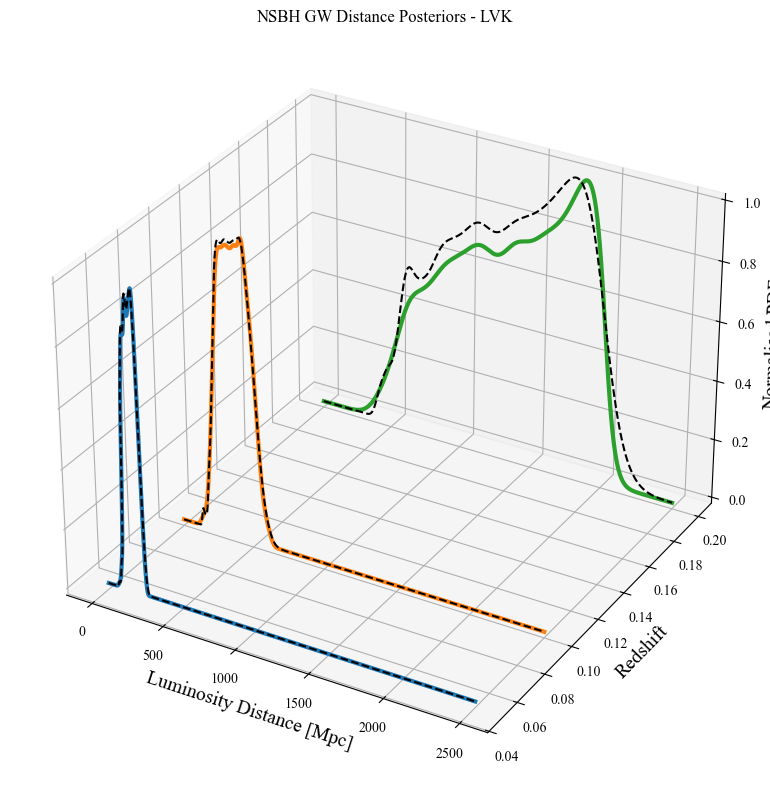

In [11]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - LVK')

for idx_z, z_val in enumerate(z_LVK_range):
    ax.plot(dL_range_LVK, np.repeat(z_val, repeats=len(dL_range_LVK)), dL_kdes_LVK[idx_z, :]/np.max(dL_kdes_LVK[idx_z, :]), lw=3)
    ax.plot(np.exp(dL_range_LVK_log), np.repeat(z_val, repeats=len(dL_range_LVK_log)),\
            dL_kdes_LVK_log[idx_z, :]/np.max(dL_kdes_LVK_log[idx_z, :]), ls='--', c='black')
    
ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised PDF', fontsize=14)

plt.tight_layout()
plt.show()

Same as above, but we plot the $\log$(pdf):

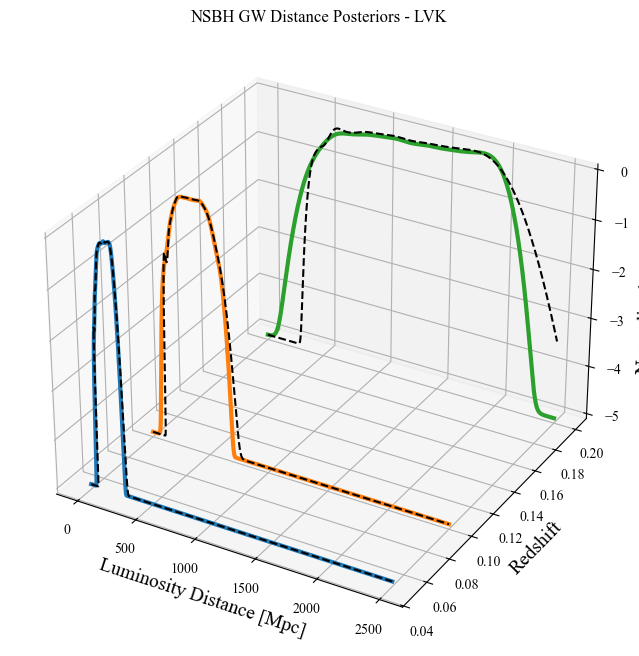

In [12]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - LVK')

for idx_z, z_val in enumerate(z_LVK_range):
    ax.plot(dL_range_LVK, np.repeat(z_val, repeats=len(dL_range_LVK)),\
            np.log10(dL_kdes_LVK[idx_z, :]/np.max(dL_kdes_LVK[idx_z, :])+1e-5), lw=3)
    ax.plot(np.exp(dL_range_LVK_log), np.repeat(z_val, repeats=len(dL_range_LVK_log)),\
            np.log10(dL_kdes_LVK_log[idx_z, :]/np.max(dL_kdes_LVK_log[idx_z, :])+1e-5), ls='--', c='black')
    
ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised Log[PDF]', fontsize=14)

plt.show()

For each simulated event, we calculate the "width" of the $D_L$ posterior:

In [13]:
dL_error_LVK = np.zeros(3)  # based on std
dL_qerror_LVK = np.zeros(3)  # based on quantile range

for i in range(3):
    dL_error_LVK[i] = np.std(dL_array_LVK[i, :])/np.median(dL_array_LVK[i, :])*100
    dL_qerror_LVK[i] = quantile_range(dL_array_LVK[i, :], 0.158, 0.842)/2/np.median(dL_array_LVK[i, :])*100
    print("std based error: ", round(dL_error_LVK[i],2), "and quantile based error: ", round(dL_qerror_LVK[i], 2))

std based error:  20.71 and quantile based error:  23.22
std based error:  25.71 and quantile based error:  28.22
std based error:  30.74 and quantile based error:  35.42


**Note**: The `std` and `quantile` based errors are a bit different, as expected (with the quantile slightly larger), but the difference is not that big (for our purposes).

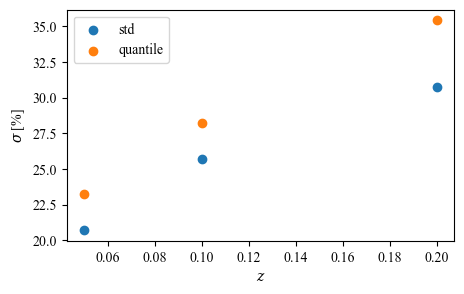

In [14]:
fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, label='std')
ax1.scatter(z_LVK_range, dL_qerror_LVK, label='quantile')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Fit based on Standard deviations**

We interpolate the error estimates in the whole redshift range of interest. For all cases, we use a **linear** and a **quadratic** fit.

In [15]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_error_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [16]:
popt_LVK_std, _ = curve_fit(func_quad, z_LVK_range, dL_error_LVK)  # Quadratic fit
popt_lin_LVK_std, _ = curve_fit(func_lin, z_LVK_range, dL_error_LVK)  # Linear fit

C:\Users\klera\AppData\Local\Temp\ipykernel_4456\2960506037.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK_std, _ = curve_fit(func_quad, z_LVK_range, dL_error_LVK)  # Quadratic fit


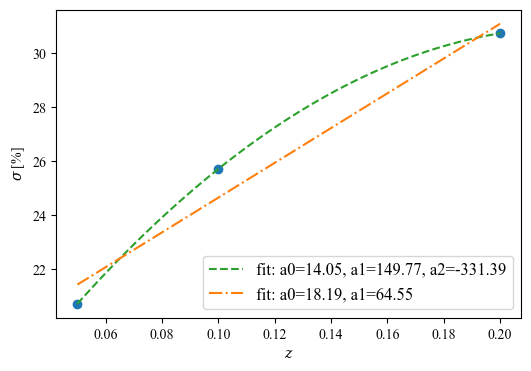

In [17]:
fig = plt.figure(figsize=(6, 4))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK_std), ls='--', c='tab:green', label='fit: a0=%5.2f, a1=%5.2f, a2=%5.2f' % tuple(popt_LVK_std))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK_std), ls='-.', c='tab:orange', label='fit: a0=%5.2f, a1=%5.2f' % tuple(popt_lin_LVK_std))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend(fontsize=12, loc='lower right')

plt.show()

**Fit based on Quantiles**

In [18]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_qerror_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [19]:
popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_qerror_LVK)  # Quadratic fit
popt_lin_LVK, _ = curve_fit(func_lin, z_LVK_range, dL_qerror_LVK)  # Linear fit

C:\Users\klera\AppData\Local\Temp\ipykernel_4456\2496503250.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_qerror_LVK)  # Quadratic fit


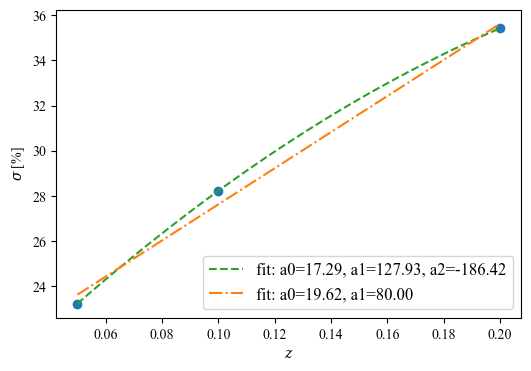

In [20]:
fig = plt.figure(figsize=(6, 4))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_qerror_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK), ls='--', c='tab:green', label='fit: a0=%5.2f, a1=%5.2f, a2=%5.2f' % tuple(popt_LVK))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.2f, a1=%5.2f' % tuple(popt_lin_LVK))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend(fontsize=12, loc='lower right')

plt.show()

## CE samples analysis

Same as above, but for the CE samples.

In [21]:
N_draw_samples = 5000
dL_res = int(5e3)
data_files = dist_names[3:]

dL_array_CE = np.zeros((len(data_files), N_draw_samples))
dL_kdes_CE = np.zeros((len(data_files), dL_res))
dL_kdes_CE_log = np.zeros((len(data_files), dL_res))

dL_range_CE = np.linspace(0, 20000, dL_res)
dL_range_CE_log = np.log(np.linspace(0.01, 20000, dL_res))

for idx, name in enumerate(data_files):
    dL_array_CE[idx, :], dL_kde, dL_kde_log = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes_CE[idx, :] = dL_kde(dL_range_CE)
    dL_kdes_CE_log[idx, :] = dL_kde_log(dL_range_CE_log)/np.exp(dL_range_CE_log)

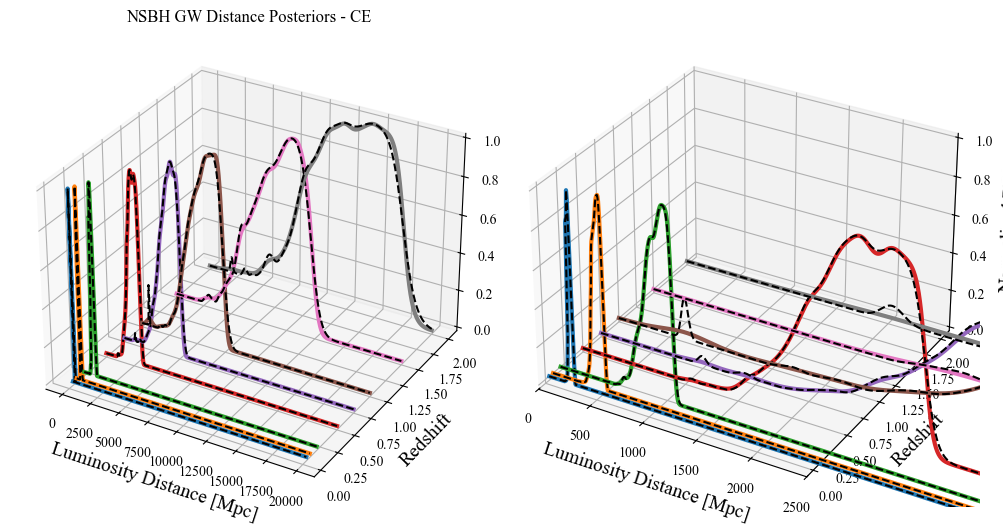

In [22]:
fig = plt.figure(figsize = (10, 8))
ax1 = fig.add_subplot(121, projection = '3d')
ax2 = fig.add_subplot(122, projection = '3d')

ax1.title.set_text('NSBH GW Distance Posteriors - CE')

for idx_z, z_val in enumerate(z_CE_range):
    ax1.plot(dL_range_CE, np.repeat(z_val, repeats=len(dL_range_CE)), dL_kdes_CE[idx_z, :]/np.max(dL_kdes_CE[idx_z, :]), lw=3)
    ax1.plot(np.exp(dL_range_CE_log), np.repeat(z_val, repeats=len(dL_range_CE_log)),\
            dL_kdes_CE_log[idx_z, :]/np.max(dL_kdes_CE_log[idx_z, :]), ls='--', c='black')
    
ax1.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax1.set_ylabel('Redshift', fontsize=14)
ax1.set_zlabel('Normalised PDF', fontsize=14)

for idx_z, z_val in enumerate(z_CE_range):
    ax2.plot(dL_range_CE, np.repeat(z_val, repeats=len(dL_range_CE)), dL_kdes_CE[idx_z, :]/np.max(dL_kdes_CE[idx_z, :]), lw=3)
    ax2.plot(np.exp(dL_range_CE_log), np.repeat(z_val, repeats=len(dL_range_CE_log)),\
            dL_kdes_CE_log[idx_z, :]/np.max(dL_kdes_CE_log[idx_z, :]), ls='--', c='black')
    
ax2.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax2.set_ylabel('Redshift', fontsize=14)
ax2.set_zlabel('Normalised PDF', fontsize=14)
ax2.set_xlim(0, 2500)

plt.tight_layout()
plt.show()

Same as above, but we plot the $\log$(pdf):

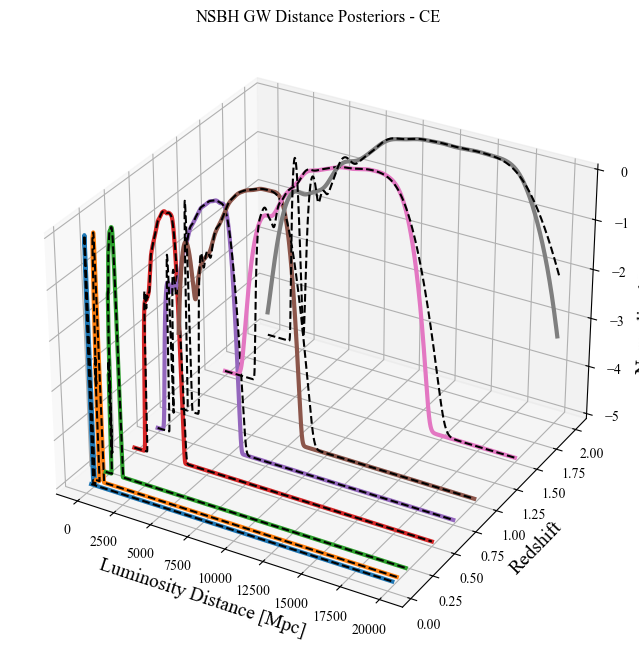

In [23]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - CE')

for idx_z, z_val in enumerate(z_CE_range):
    ax.plot(dL_range_CE, np.repeat(z_val, repeats=len(dL_range_CE)),\
            np.log10(dL_kdes_CE[idx_z, :]/np.max(dL_kdes_CE[idx_z, :])+1e-5), lw=3)
    ax.plot(np.exp(dL_range_CE_log), np.repeat(z_val, repeats=len(dL_range_CE_log)),\
            np.log10(dL_kdes_CE_log[idx_z, :]/np.max(dL_kdes_CE_log[idx_z, :])+1e-5), ls='--', c='black')
    
ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised Log[PDF]', fontsize=14)

plt.show()

For each simulated event, we calculate the "width" of the $D_L$ posterior:

In [24]:
dL_error_CE = np.zeros(8)
dL_qerror_CE = np.zeros(8)

for i in range(8):
    dL_error_CE[i] = np.std(dL_array_CE[i, :])/np.median(dL_array_CE[i, :])*100
    dL_qerror_CE[i] = quantile_range(dL_array_CE[i, :], 0.158, 0.842)/2/np.median(dL_array_CE[i, :])*100    
    print("std based error: ", round(dL_error_CE[i], 2), "and quantile based error: ", round(dL_qerror_CE[i], 2))

std based error:  6.89 and quantile based error:  7.16
std based error:  8.86 and quantile based error:  9.44
std based error:  11.28 and quantile based error:  11.79
std based error:  15.59 and quantile based error:  16.59
std based error:  17.88 and quantile based error:  18.6
std based error:  21.15 and quantile based error:  22.17
std based error:  22.04 and quantile based error:  23.92
std based error:  24.22 and quantile based error:  26.37


**Note**: As before, note that the quantile errors are slightly larger.

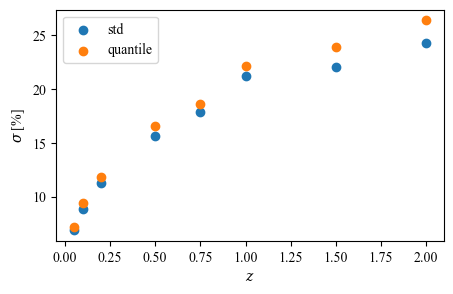

In [25]:
fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE, label='std')
ax1.scatter(z_CE_range, dL_qerror_CE, label='quantile')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Fit based on Standard deviations**

In [26]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_error_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [27]:
popt_CE_std, _ = curve_fit(func_quad, z_CE_range, dL_error_CE)
popt_lin_CE_std, _ = curve_fit(func_lin, z_CE_range, dL_error_CE)

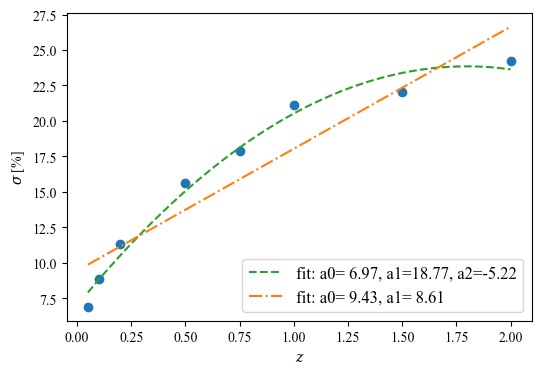

In [28]:
fig = plt.figure(figsize=(6, 4))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE_std), ls='--', c='tab:green', label='fit: a0=%5.2f, a1=%5.2f, a2=%5.2f' % tuple(popt_CE_std))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE_std), ls='-.', c='tab:orange', label='fit: a0=%5.2f, a1=%5.2f' % tuple(popt_lin_CE_std))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend(fontsize=12, loc='lower right')

plt.show()

**Fit based on Quantiles**

In [29]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_qerror_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [30]:
popt_CE, pcov_CE = curve_fit(func_quad, z_CE_range, dL_qerror_CE)
popt_lin_CE, pcov_CE = curve_fit(func_lin, z_CE_range, dL_qerror_CE)

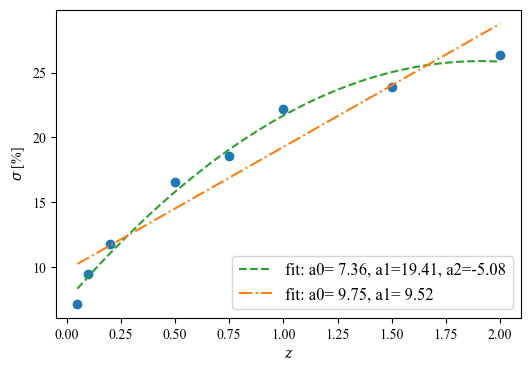

In [31]:
fig = plt.figure(figsize=(6, 4))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_qerror_CE)
ax1.plot(z_detailed, sigma_interpolation, ls=' ', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE), ls='--', c='tab:green', label='fit: a0=%5.2f, a1=%5.2f, a2=%5.2f' % tuple(popt_CE))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:orange', label='fit: a0=%5.2f, a1=%5.2f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend(fontsize=12, loc='lower right')

plt.show()

------------------------

## Comparison between LVK and CE results

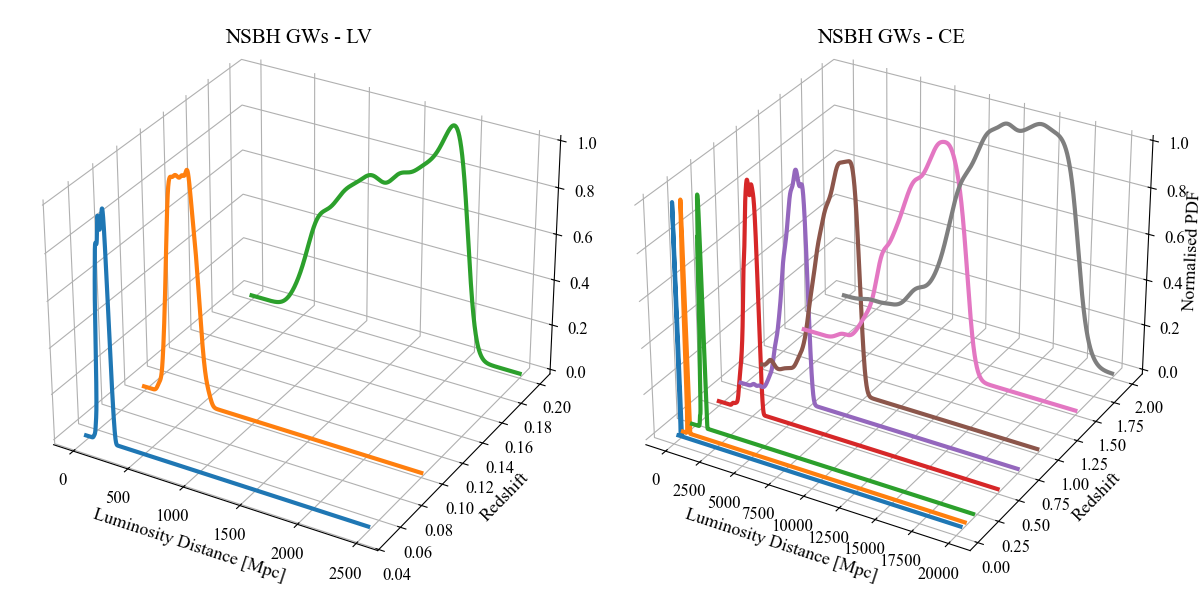

In [32]:
fig = plt.figure(figsize = (12, 12))
ax1 = fig.add_subplot(121, projection = '3d')
ax2 = fig.add_subplot(122, projection = '3d')

ax1.set_title('NSBH GWs - LV', y=1.01, fontsize=15)

for idx_z, z_val in enumerate(z_LVK_range):
    ax1.plot(dL_range_LVK, np.repeat(z_val, repeats=len(dL_range_LVK)), dL_kdes_LVK[idx_z, :]/np.max(dL_kdes_LVK[idx_z, :]), lw=3)

ax1.set_xlabel('Luminosity Distance [Mpc]', fontsize=13)
ax1.set_ylabel('Redshift', fontsize=13)
# ax1.set_zlabel('Normalised PDF', fontsize=14)

# Get rid of the panes
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.tick_params(axis='both', which='major', labelsize=12)

ax2.set_title('NSBH GWs - CE', y=1.01, fontsize=15)

for idx_z, z_val in enumerate(z_CE_range):
    ax2.plot(dL_range_CE, np.repeat(z_val, repeats=len(dL_range_CE)), dL_kdes_CE[idx_z, :]/np.max(dL_kdes_CE[idx_z, :]), lw=3)

ax2.set_xlabel('Luminosity Distance [Mpc]', fontsize=13)
ax2.set_ylabel('Redshift', fontsize=13)
ax2.set_zlabel('Normalised PDF', labelpad=-0.9, fontsize=13)

# Get rid of the panes
ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax2.tick_params(axis='both', which='major', labelsize=12)

# ax2.set_box_aspect(None, zoom=0.9)

plt.tight_layout(pad=1.1)


if SAVE_FIG:
    plt.savefig("figures/DL_posteriors_LV_CE.png", dpi=450, bbox_inches='tight')

# fig.get_layout_engine().set(w_pad=0.0, h_pad=0.0, hspace=10.5,
#                             wspace=0.05)

plt.show()
plt.close()

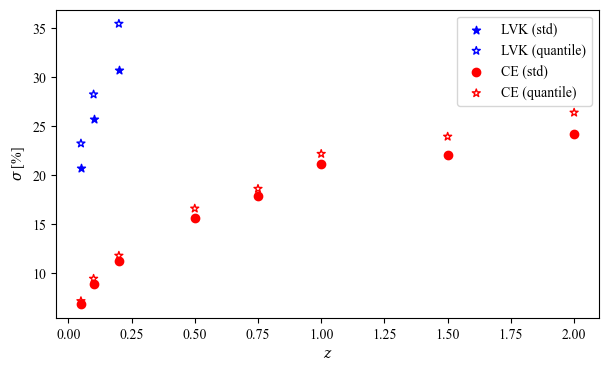

In [37]:
fig = plt.figure(figsize=(7, 4))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, marker='*', c='blue', label='LVK (std)')
ax1.scatter(z_LVK_range, dL_qerror_LVK, marker='*', facecolors='none', edgecolors='blue', label='LVK (quantile)')
ax1.scatter(z_CE_range, dL_error_CE, c='r', label='CE (std)')
ax1.scatter(z_CE_range, dL_qerror_CE, marker='*', facecolors='none', edgecolors='red', label='CE (quantile)')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

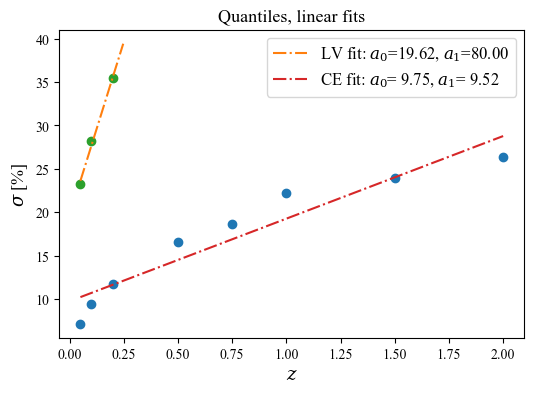

In [49]:
fig = plt.figure(figsize=(6, 4))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_qerror_LVK, c='tab:green')
plt.plot(z_detailed[z_detailed<0.25], func_lin(z_detailed[z_detailed<0.25], *popt_lin_LVK), ls='-.', c='tab:orange',\
         label=r'LV fit: $a_0$=%5.2f, $a_1$=%5.2f' % tuple(popt_lin_LVK))

ax1.scatter(z_CE_range, dL_qerror_CE, c='tab:blue')
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:red', label=r'CE fit: $a_0$=%5.2f, $a_1$=%5.2f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$', fontsize=13)
ax1.set_ylabel(r'$\sigma$ [%]', fontsize=13)
ax1.legend(fontsize=12)
ax1.set_title('Quantiles, linear fits', fontsize=13)

if SAVE_FIG:
    plt.savefig("figures/Quantiles_linear_fit_LV_CE.png", dpi=450, bbox_inches='tight')

plt.show()

----------------------------

**Saving the linear interpolations**

Note that we are saving: $\sigma_{d_L}/d_L \times 100$. This is important, when we want to use the interpolation in the main code.

In [50]:
np.savez('quantile_linear_interpolations.npz', LVK_interpolation = popt_lin_LVK, CE_interpolation = popt_lin_CE)

----------------------------------------------------

## 2D interpolation

In [57]:
from scipy.interpolate import RegularGridInterpolator

**LVK interpolation**

In [91]:
## Drawing and renormalising samples

N_draw_samples = 5000
dL_res = int(5e3)
data_files = dist_names[:3]

dL_array_LVK = np.zeros((len(data_files), N_draw_samples))
dL_kdes_LVK = np.zeros((len(data_files), dL_res))
dL_kdes_LVK_log = np.zeros((len(data_files), dL_res))

dL_range_LVK = np.linspace(0, 2500, dL_res)
dL_range_LVK_log = np.log(np.linspace(0.01, 2500, dL_res))

for idx, name in enumerate(data_files):
    dL_array_LVK[idx, :], dL_kde, dL_kde_log = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes_LVK[idx, :] = dL_kde(dL_range_LVK)
    dL_kdes_LVK_log[idx, :] = dL_kde_log(dL_range_LVK_log)/np.exp(dL_range_LVK_log)

Selecting the points on the grid, which are going to be used as the basis of the interpolation

In [92]:
N_points = 50
Step_size = dL_res//N_points

dL_points = np.zeros((len(data_files), N_points))

for idx, name in enumerate(data_files):
    dL_points[idx, :] = dL_kdes_LVK[idx, ::Step_size]

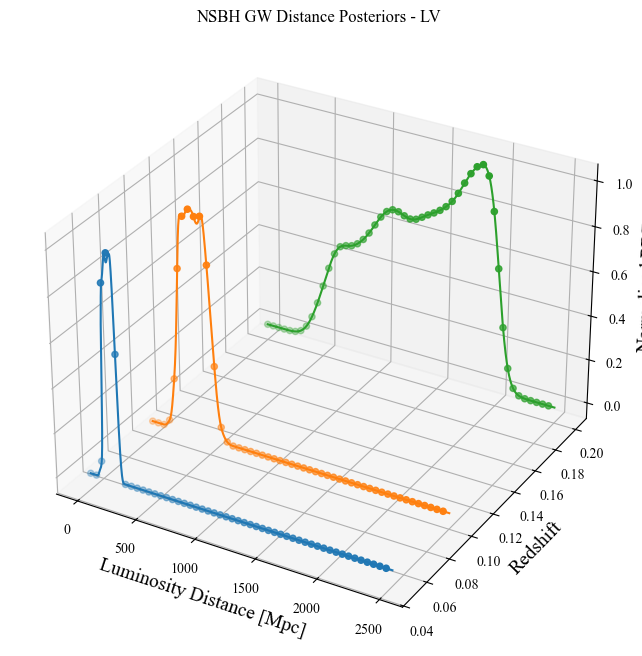

In [93]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - LV')

for idx_z, z_val in enumerate(z_LVK_range):
    ax.plot(dL_range_LVK, np.repeat(z_val, repeats=len(dL_range_LVK)), dL_kdes_LVK[idx_z, :]/np.max(dL_kdes_LVK[idx_z, :]))
    ax.scatter(dL_range_LVK[::Step_size], np.repeat(z_val, repeats=len(dL_range_LVK[::Step_size])),\
               dL_points[idx_z,:]/np.max(dL_points[idx_z,:]))

ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised PDF', fontsize=14)

plt.show()

Interpolation procedure

In [94]:
## Choosing grid range
x, y = dL_range_LVK[::Step_size], z_LVK_range

## Normalising the points (as we did with the pdfs)
dL_points_norm = dL_points/(np.max(dL_points, axis=1)).reshape(len(z_LVK_range), 1)

## Linear interpolation on the grid selection (x, y) over the point selection (dL_points)
interp = RegularGridInterpolator((x, y), dL_points_norm.T,
                                 bounds_error=False, method='linear', fill_value=None)

## TEST - Linear interpolation on the grid selection (x, y) over the point selection (dL_points) without normalisation
interp_unnormalised = RegularGridInterpolator((x, y), dL_points.T,
                                 bounds_error=False, method='linear', fill_value=None)

In [95]:
## Log interpolation

dL_points_norm_log = np.log10(dL_points_norm+1e-5)

interp_log = RegularGridInterpolator((x, y), dL_points_norm_log.T,
                                 bounds_error=False, method='linear', fill_value=None)

In [96]:
xx = dL_range_LVK
yy = np.linspace(np.min(z_LVK_range), np.max(z_LVK_range), 10)
X, Y = np.meshgrid(xx, yy, indexing='ij')

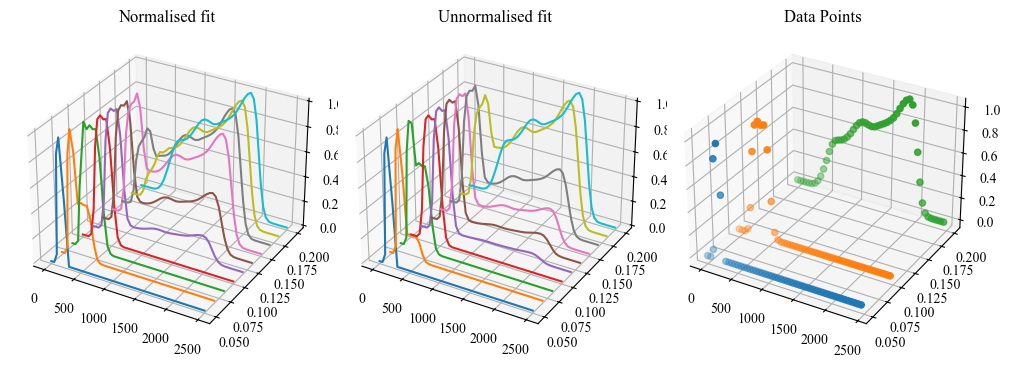

In [97]:
fig = plt.figure(figsize = (10, 8))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# ax.scatter(xg.ravel(), yg.ravel(), data.ravel(),
#            s=60, c='k', label='data')

for idx, z_yy in enumerate(yy):
    ax1.plot(dL_range_LVK, np.repeat(z_yy, repeats=len(dL_range_LVK)),\
             interp((X, Y))[:, idx]/np.max(interp((X, Y))[:, idx]))

for idx, z_yy in enumerate(yy):
    ax2.plot(dL_range_LVK, np.repeat(z_yy, repeats=len(dL_range_LVK)),\
             interp_unnormalised((X, Y))[:, idx]/np.max(interp_unnormalised((X, Y))[:, idx]))

for idx, z_LVK in enumerate(z_LVK_range):
    ax3.scatter(dL_range_LVK[::Step_size], np.repeat(z_LVK, repeats=len(dL_range_LVK[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))

ax1.set_title("Normalised fit")
ax2.set_title("Unnormalised fit")
ax3.set_title("Data Points")

# # ground truth
# ax.plot_wireframe(X, Y, ff(X, Y), rstride=3, cstride=3,
#                   alpha=0.4, label='ground truth')
# plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-success">
<b>LV interpolation notes:</b> 
    
- Normalised fit tries to create this long tail to transition smoothly from the more precise pdfs to the wider one at larger redshifts.
  
- Unnormalised fit emphasizes the low distance peak too much, and just add a tail.

- Neither fit is good! The main problem is that we have grid data points on only 3 redshifts, so the interpolation has a lot of freedom and the simulated data do not constrain it enough.
</div>

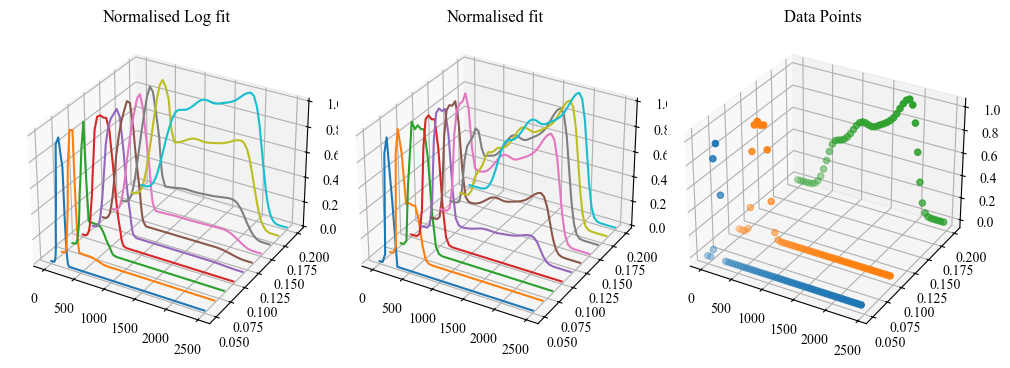

In [98]:
fig = plt.figure(figsize = (10, 8))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# ax.scatter(xg.ravel(), yg.ravel(), data.ravel(),
#            s=60, c='k', label='data')

for idx, z_yy in enumerate(yy):
    ax1.plot(dL_range_LVK, np.repeat(z_yy, repeats=len(dL_range_LVK)),\
             np.exp(interp_log((X, Y))[:, idx])/np.max(np.exp(interp_log((X, Y))[:, idx])))
ax1.set_title("Normalised Log fit")

for idx, z_yy in enumerate(yy):
    ax2.plot(dL_range_LVK, np.repeat(z_yy, repeats=len(dL_range_LVK)),\
             interp((X, Y))[:, idx]/np.max(interp((X, Y))[:, idx]))
ax2.set_title("Normalised fit")

for idx, z_LVK in enumerate(z_LVK_range):
    ax3.scatter(dL_range_LVK[::Step_size], np.repeat(z_LVK, repeats=len(dL_range_LVK[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))
ax3.set_title("Data Points")

plt.tight_layout()
plt.show()

<div class="alert alert-success">
<b>LV interpolation notes (part 2):</b> 
    
- Finally, we tried a fit using the log data points, and interpolated in log space. The fit is slightly smoother, but, still the main issue is that there are not enough simulated data at different redshifts.
  
- For LV, it is probably better to use the quantile linear fits.
</div>

**CE interpolation**

In [99]:
N_draw_samples = 5000
dL_res = int(5e3)
data_files = dist_names[3:]

dL_array_CE = np.zeros((len(data_files), N_draw_samples))
dL_kdes_CE = np.zeros((len(data_files), dL_res))
dL_kdes_CE_log = np.zeros((len(data_files), dL_res))

dL_range_CE = np.linspace(0, 20000, dL_res)
dL_range_CE_log = np.log(np.linspace(0.01, 20000, dL_res))

for idx, name in enumerate(data_files):
    dL_array_CE[idx, :], dL_kde, dL_kde_log = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes_CE[idx, :] = dL_kde(dL_range_CE)
    dL_kdes_CE_log[idx, :] = dL_kde_log(dL_range_CE_log)/np.exp(dL_range_CE_log)

Selecting the points on the grid, which are going to be used as the basis of the interpolation

In [100]:
N_points = 500  ## We use more points here, to make sure we cover the very precise peaks at lower redshifts
Step_size = dL_res//N_points

dL_points = np.zeros((len(data_files), N_points))

for idx, name in enumerate(data_files):
    dL_points[idx, :] = dL_kdes_CE[idx, ::Step_size]

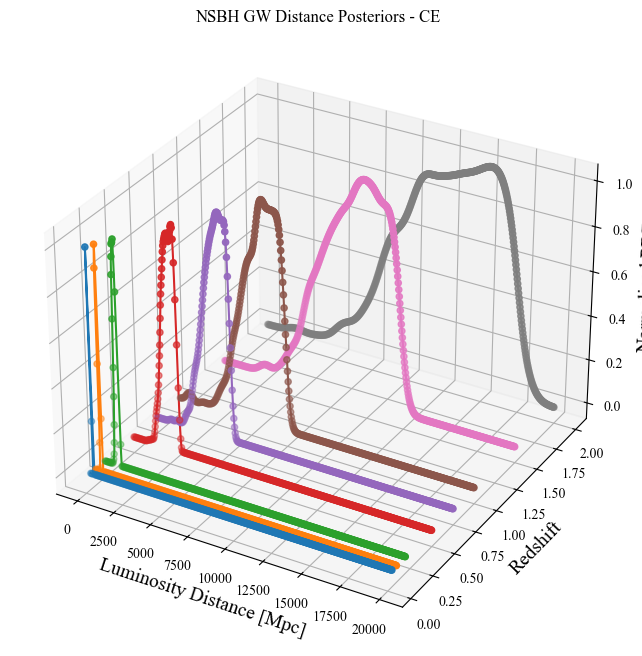

In [101]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = '3d')

ax.title.set_text('NSBH GW Distance Posteriors - CE')

for idx, z_CE in enumerate(z_CE_range):
    ax.plot(dL_range_CE, np.repeat(z_CE, repeats=len(dL_range_CE)), dL_kdes_CE[idx, :]/np.max(dL_kdes_CE[idx, :]))
    ax.scatter(dL_range_CE[::Step_size], np.repeat(z_CE, repeats=len(dL_range_CE[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))

ax.set_xlabel('Luminosity Distance [Mpc]', fontsize=14)
ax.set_ylabel('Redshift', fontsize=14)
ax.set_zlabel('Normalised PDF', fontsize=14)

plt.show()

Interpolation procedure

In [102]:
## Choosing grid range
x, y = dL_range_CE[::Step_size], z_CE_range

## Normalising the points (as we did with the pdfs)
dL_points_norm = dL_points/(np.max(dL_points, axis=1).reshape(len(z_CE_range), 1))

## Linear interpolation on the grid selection (x, y) over the point selection (dL_points)
interp = RegularGridInterpolator((x, y), dL_points_norm.T,
                                 bounds_error=False, method='linear', fill_value=None)

## TEST - Linear interpolation on the grid selection (x, y) over the point selection (dL_points) without normalisation
interp_unnormalised = RegularGridInterpolator((x, y), dL_points.T,
                                 bounds_error=False, method='linear', fill_value=None)

In [103]:
## Log interpolation

dL_points_norm_log = np.log10(dL_points_norm+1e-5)

interp_log = RegularGridInterpolator((x, y), dL_points_norm_log.T,
                                 bounds_error=False, method='linear', fill_value=None)

In [149]:
xx = dL_range_CE
yy = np.linspace(np.min(z_CE_range), np.max(z_CE_range), 15)
X, Y = np.meshgrid(xx, yy, indexing='ij')

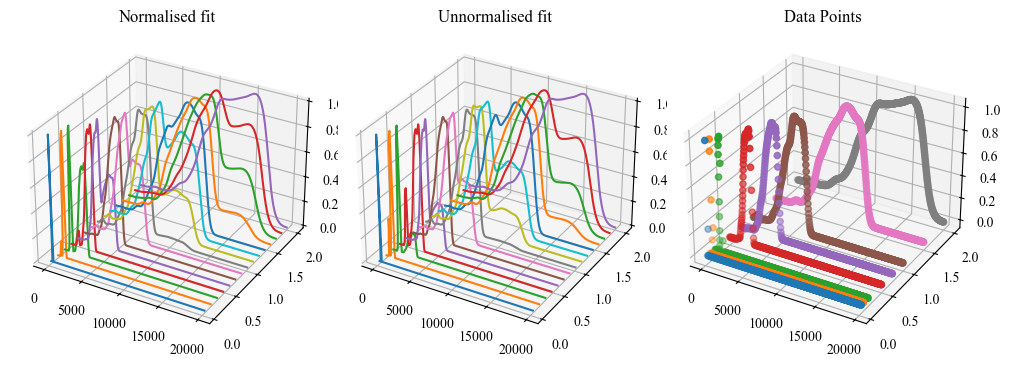

In [150]:
fig = plt.figure(figsize = (10, 8))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# ax.scatter(xg.ravel(), yg.ravel(), data.ravel(),
#            s=60, c='k', label='data')

for idx, z_yy in enumerate(yy):
    ax1.plot(dL_range_CE, np.repeat(z_yy, repeats=len(dL_range_CE)),\
            interp((X, Y))[:, idx]/np.max(interp((X, Y))[:, idx]))

for idx, z_yy in enumerate(yy):
    ax2.plot(dL_range_CE, np.repeat(z_yy, repeats=len(dL_range_CE)),\
             interp_unnormalised((X, Y))[:, idx]/np.max(interp_unnormalised((X, Y))[:, idx]))

for idx, z_CE in enumerate(z_CE_range):
    ax3.scatter(dL_range_CE[::Step_size], np.repeat(z_CE, repeats=len(dL_range_CE[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))

ax1.set_title("Normalised fit")
ax2.set_title("Unnormalised fit")
ax3.set_title("Data Points")

plt.tight_layout()
plt.show()

<div class="alert alert-success">
<b>CE interpolation notes:</b> 
    
- Fits are a bit smoother in their transitions - although there are some bimodalities not present in the simulated data.

- The extra redshift data points help.
</div>

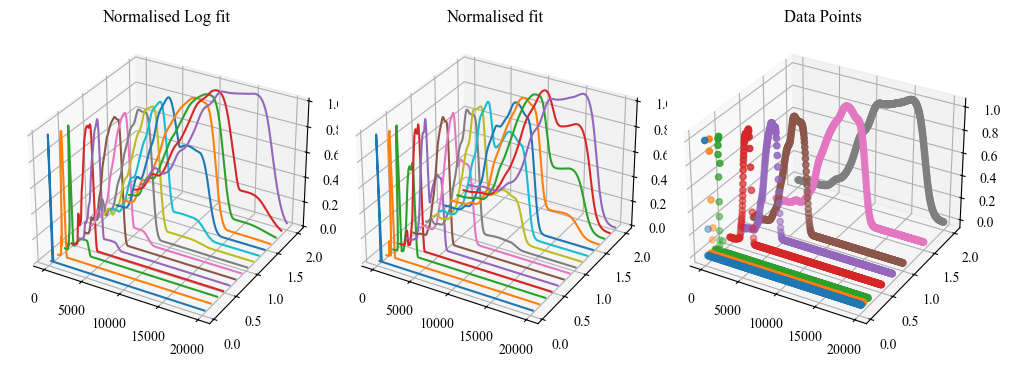

In [151]:
fig = plt.figure(figsize = (10, 8))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

for idx, z_yy in enumerate(yy):
    ax1.plot(dL_range_CE, np.repeat(z_yy, repeats=len(dL_range_CE)),\
             np.exp(interp_log((X, Y))[:, idx])/np.max(np.exp(interp_log((X, Y))[:, idx])))
ax1.set_title("Normalised Log fit")

for idx, z_yy in enumerate(yy):
    ax2.plot(dL_range_CE, np.repeat(z_yy, repeats=len(dL_range_CE)),\
            interp((X, Y))[:, idx]/np.max(interp((X, Y))[:, idx]))
ax2.set_title("Normalised fit")

for idx, z_CE in enumerate(z_CE_range):
    ax3.scatter(dL_range_CE[::Step_size], np.repeat(z_CE, repeats=len(dL_range_CE[::Step_size])),\
               dL_points[idx,:]/np.max(dL_points[idx,:]))
ax3.set_title("Data Points")

plt.tight_layout()
plt.show()

<div class="alert alert-success">
<b>CE interpolation notes (part 2):</b> 
    
- The log fit is slightly better - less bimodality and smoother transition. There are small tails that are unphysical.
</div>

**2D interpolations - Linear Fits**

In [154]:
dL_qerror_2DCE = np.zeros_like(yy)
dL_qerror_2DlogCE = np.zeros_like(yy)

for idx, z_val in enumerate(yy):
    dL_pdf_2D = interp((X, Y))[:, idx]/np.max(interp((X, Y))[:, idx])
    dL_pdf_2Dlog = np.exp(interp_log((X, Y))[:, idx])/np.max(np.exp(interp_log((X, Y))[:, idx]))

    bool_pdf_2D = (dL_pdf_2D>=0)  # There are some values smaller than 0 (these are unphysical and problem of the interpolation
    bool_pdf_2Dlog = (dL_pdf_2Dlog>=0)
    
    dL_array_2D = rng.choice(dL_range_CE[bool_pdf_2D], p=dL_pdf_2D[bool_pdf_2D]/np.sum(dL_pdf_2D[bool_pdf_2D]),\
                             size=len(dL_pdf_2D)*2, replace=True)
    dL_array_2Dlog = rng.choice(dL_range_CE[bool_pdf_2Dlog], p=dL_pdf_2Dlog[bool_pdf_2Dlog]/np.sum(dL_pdf_2Dlog[bool_pdf_2Dlog]),\
                                size=len(dL_pdf_2Dlog)*2, replace=True)
   
    dL_qerror_2DCE[idx] = quantile_range(dL_array_2D, 0.158, 0.842)/2/np.median(dL_array_2D)*100
    dL_qerror_2DlogCE[idx] = quantile_range(dL_array_2Dlog, 0.158, 0.842)/2/np.median(dL_array_2Dlog)*100

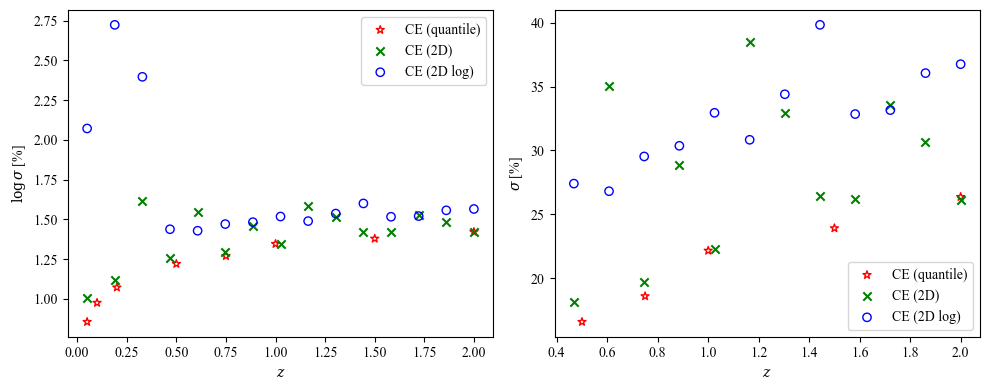

In [168]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.scatter(z_CE_range, np.log10(dL_qerror_CE), marker='*', facecolors='none', edgecolors='red', label='CE (quantile)')
ax1.scatter(yy, np.log10(dL_qerror_2DCE), marker='x', facecolors='green', label='CE (2D)')
ax1.scatter(yy, np.log10(dL_qerror_2DlogCE), marker='o', facecolors='none', edgecolors='blue', label='CE (2D log)')

ax2.scatter(np.array(z_CE_range)[np.array(z_CE_range)>0.4], dL_qerror_CE[np.array(z_CE_range)>0.4],\
            marker='*', facecolors='none', edgecolors='red', label='CE (quantile)')
ax2.scatter(yy[yy>0.4], dL_qerror_2DCE[yy>0.4], marker='x', facecolors='green', label='CE (2D)')
ax2.scatter(yy[yy>0.4], dL_qerror_2DlogCE[yy>0.4], marker='o', facecolors='none', edgecolors='blue', label='CE (2D log)')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\log \sigma$ [%]')
ax1.legend()

ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'$\sigma$ [%]')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Note**: At low-z, where the simulated values are very precise, the interpolations cannot get a good fit (there are bimodalities that lead to unphysically large errors, by affecting the quantiles and the median).

In [169]:
## Linear fit for interpolated sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
popt_lin_2DCE, pcov_2DCE = curve_fit(func_lin, yy[yy>0.4], dL_qerror_2DCE[yy>0.4])
popt_lin_2DlogCE, pcov_2DlogCE = curve_fit(func_lin, yy[yy>0.4], dL_qerror_2DlogCE[yy>0.4])

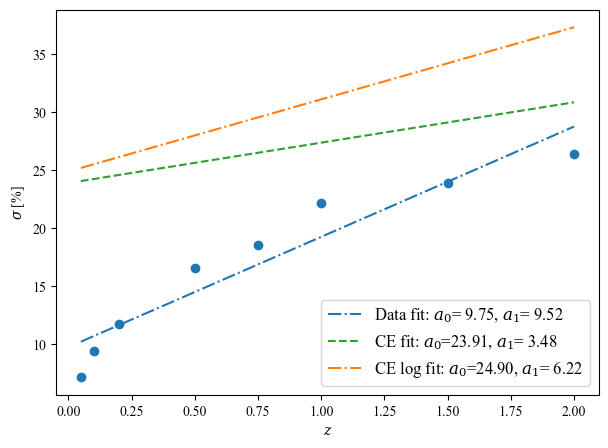

In [184]:
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_qerror_CE)
ax1.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:blue',\
         label=r'Data fit: $a_0$=%5.2f, $a_1$=%5.2f' % tuple(popt_lin_CE))
ax1.plot(z_detailed, func_lin(z_detailed, *popt_lin_2DCE), ls='--', c='tab:green',\
         label=r'CE fit: $a_0$=%5.2f, $a_1$=%5.2f' % tuple(popt_lin_2DCE))
ax1.plot(z_detailed, func_lin(z_detailed, *popt_lin_2DlogCE), ls='-.', c='tab:orange',\
         label=r'CE log fit: $a_0$=%5.2f, $a_1$=%5.2f' % tuple(popt_lin_2DlogCE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend(fontsize=12, loc='lower right')

plt.show()

**Note**: The linear fits to the errors calculated by the 2D interpolations lead to much higher errors in amplitude.